## <center> INNER JOIN

Для INNER JOIN работает следующее правило: присоединяются только те строки таблиц, которые удовлетворяют условию соединения. Если в любой из соединяемых таблиц находятся такие строки, которые не удовлетворяют заявленному условию, — они отбрасываются.

## <center> LEFT OUTER JOIN и RIGHT OUTER JOIN

Для LEFT JOIN работает следующее правило: из левой (относительно оператора) таблицы сохраняются все строки, а из правой добавляются только те, которые соответствуют условию соединения. Если в правой таблице не находится соответствия, то значения строк второй таблицы будут иметь значение NULL.

>Поставим следующую задачу: вывести полные названия команд, данных по которым нет в таблице matches.
```sql
SELECT
    t.long_name,
    m.id
FROM sql.teams t
LEFT JOIN sql.matches m ON t.api_id = m.home_team_api_id OR t.api_id = m.away_team_api_id
ORDER BY m.id DESC

Вывод: в таблице teams сохранились все записи, а в таблице matches есть пустые строки.

>Теперь, чтобы выбрать такие команды, которые не принимали участия в матчах, достаточно добавить условие where m.id is null (или любое другое поле таблицы matches).
```sql
SELECT
    t.long_name
FROM 
    sql.teams t
LEFT JOIN sql.matches m ON t.api_id = m.home_team_api_id OR t.api_id = m.away_team_api_id
WHERE m.id IS NULL

>Используя LEFT JOIN, выведите список уникальных названий команд, содержащихся в таблице matches. Отсортируйте список в алфавитном порядке.
```sql
select
    distinct t.long_name
from
    sql.matches m
    left join sql.teams t on t.api_id = m.home_team_api_id
where t.long_name is not null
order by t.long_name

С LEFT JOIN также работают агрегатные функции, что позволяет не потерять значения из левой таблицы. Например, мы можем вывести сумму голов команд по гостевым матчам.

```sql
SELECT
    t.long_name,
    SUM(m.away_team_goals) total_goals
FROM   
    sql.teams t
LEFT JOIN sql.matches m ON t.api_id = m.away_team_api_id
GROUP BY t.id
ORDER BY 2 DESC

Обратите внимание! При применении функций SUM, MIN, MAX, AVG к полям со значением NULL в результате получится NULL, а не 0. А при использовании функции COUNT, наоборот, получится 0.

>Используя LEFT JOIN, напишите запрос, который выведет полное название команды (long_name), количество матчей, в которых участвовала команда, — домашних и гостевых (matches_cnt). Отсортируйте по количеству матчей в порядке возрастания, затем — по названию команды в алфавитном порядке.
```sql
SELECT
    t.long_name,
    COUNT(m.id) matches_cnt
FROM
    sql.teams t
    LEFT JOIN sql.matches m ON t.api_id = m.home_team_api_id or t.api_id = m.away_team_api_id
GROUP BY t.id
ORDER BY 2, 1

---

При использовании RIGHT JOIN сохраняется та же логика, что и для LEFT JOIN, только за основу берётся правая таблица.

Чтобы из LEFT JOIN получить RIGHT JOIN, нужно просто поменять порядок соединения таблиц.

>Вообще, применение RIGHT JOIN считается плохим тоном, так как язык SQL читается и пишется слева направо, а такой оператор усложняет чтение запросов.

---

Оператор FULL OUTER JOIN объединяет в себе LEFT и RIGHT JOIN и позволяет сохранить кортежи обеих таблиц. Даже если не будет соответствий, мы сохраним все записи из обеих таблиц.

FULL OUTER JOIN может быть полезен в ситуациях, когда схема данных недостаточно нормализована и не хватает таблиц-справочников.

Пример: в базе данных интернет-магазина есть две таблицы — с зарегистрированными пользователями и пользователями, оформившими заказ. При этом оформить заказ можно без регистрации, а зарегистрироваться — без оформления заказа.

Предположим, что вам необходимо получить полный список пользователей — и оформивших заказ, и зарегистрированных, — но в базе данных этой объединённой таблицы нет. В данном случае можно использовать FULL OUTER JOIN для получения полного списка, соединив таким образом таблицы c заказами и регистрациями по id пользователя.

>Синтаксис FULL OUTER JOIN аналогичен другим JOIN.
```sql
SELECT 
…
FROM
	table1
FULL OUTER JOIN table2 ON условие

---

CROSS JOIN соединяет таблицы так, что каждая запись в первой таблице присоединяется к каждой записи во второй таблице, иначе говоря, даёт декартово произведение.

```sql
SELECT *
FROM
    sql.teams,
    sql.matches

```sql
SELECT *
FROM
    sql.teams
    CROSS JOIN sql.matches

>Обратите внимание! Условие для CROSS JOIN, в отличие от других операторов, не требуется.

```sql
SELECT *
FROM
    sql.teams
    JOIN sql.matches ON TRUE

>CROSS JOIN может быть полезен, когда необходимо создать таблицу фактов.

Например, с помощью такого запроса мы можем получить все возможные комбинации полных названий команд в матчах.

```sql
SELECT
    DISTINCT
    t1.long_name home_team, 
    t2.long_name away_team
FROM
    sql.teams t1
    CROSS JOIN sql.teams t2

>Напишите запрос, который выведет все возможные уникальные комбинации коротких названий домашней команды (home_team) и коротких названий гостевой команды (away_team). Команда не может сама с собой играть, то есть быть и домашней, и одновременно гостевой (в одном и том же матче). Отсортируйте запрос по первому и второму столбцам.
```sql
select distinct
    t1.short_name home_team,
    t2.short_name away_team
from
    sql.teams t1
    cross join sql.teams t2
where t1.short_name <> t2.short_name
order by 1,2

---

NATURAL JOIN

Ключевое слово natural в начале оператора JOIN позволяет не указывать условие соединения таблиц — для соединения будут использованы столбцы с одинаковым названием из этих таблиц.

NATURAL JOIN можно использовать с любыми видами соединений, которые требуют условия соединения:
* NATURAL INNER JOIN (возможна запись NATURAL JOIN);
* NATURAL LEFT JOIN;
* NATURAL RIGHT JOIN;
* NATURAL FULL OUTER JOIN.

При использовании NATURAL JOIN прежде всего стоит обратить внимание на ключи таблиц. Для наших таблиц teams и matches этот вид соединения не подойдёт, так как общим для обеих таблиц является столбец id, но таблицы соединяются по другим столбцам.

Когда у таблиц есть несколько столбцов с одинаковыми именами, при NATURAL JOIN условие соединения будет применено на все столбцы с одинаковыми именами.

При построении запроса с несколькими JOIN старайтесь идти слева направо. Сначала выберите таблицу, которая является центральной в соответствии с поставленной задачей, вопросом. Затем добавляйте таблицы поэтапно в зависимости от бизнес-логики запроса.

Например, для ответа на вопрос: «Какая команда сыграла больше всех матчей в сезоне 2010/2011?» в качестве центральной лучше выбрать таблицу с командами.

А для ответа на вопрос: «В каком сезоне участвовало больше всего команд?» — таблицу с матчами.

---
5 задач в конце модуля


---

>Напишите запрос, который выведет список уникальных полных названий команд (long_name), игравших в гостях в матчах сезона 2012/2013. Отсортируйте список в алфавитном порядке.
```sql
select distinct
    t.long_name

from
    sql.teams t
    join sql.matches m on t.api_id = m.away_team_api_id
where m.season = '2012/2013'
order by t.long_name

>Напишите запрос, который выведет полное название команды (long_name) и общее количество матчей (matches_cnt), сыгранных командой Inter в домашних матчах.
```sql
select
    t.long_name,
    count(m.id) matches_cnt
from
    sql.teams t
    join sql.matches m on t.api_id = m.home_team_api_id
where t.long_name = 'Inter'
group by  t.long_name

>Напишите запрос, который выведет топ-10 команд (long_name) по суммарному количеству забитых голов в гостевых матчах. Во втором столбце запроса выведите суммарное количество голов в гостевых матчах (total_goals).
```sql
select
    t.long_name,
    sum(m.away_team_goals) total_goals
from
    sql.teams t
    join sql.matches m on t.api_id = m.away_team_api_id
group by t.long_name
order by sum(m.away_team_goals) desc
limit 10

>Выведите количество матчей между командами Real Madrid CF и FC Barcelona. В поле ниже введите запрос, с помощью которого вы решили задание.
```sql
select
    count(m.id)
from
    sql.matches m
    join sql.teams t on t.api_id = m.away_team_api_id
    join sql.teams t2 on t2.api_id = m.home_team_api_id
where (t.long_name = 'Real Madrid CF' and t2.long_name = 'FC Barcelona') or 
(t.long_name = 'FC Barcelona' and t2.long_name = 'Real Madrid CF')


>Напишите запрос, который выведет название команды (long_name), сезон (season) и суммарное количество забитых голов в домашних матчах (total_goals). Оставьте только те строки, в которых суммарное количество голов менее десяти. Отсортируйте запрос по названию команды, а затем — по сезону.
```sql
select
    t.long_name,
    m.season,
    sum(m.home_team_goals) total_goals
from
    sql.teams t
    join sql.matches m on t.api_id = m.home_team_api_id
group by t.long_name, m.season
having sum(m.home_team_goals) < 10
order by t.long_name, m.season

>Перед вами школьная таблица TABLE_A с оценками от 0 до 100, выставленными ученикам нескольких классов. 
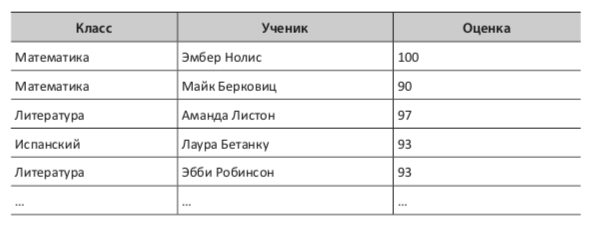

Как бы вы рассчитали максимальную оценку в каждом классе?

Запрос для поиска наивысшей оценки в каждом классе может выглядеть так:
```sql
SELECT 
  CLASS, 
  MAX(GRADE) INTO TABLE_B 
FROM 
  TABLE_A 
GROUP BY 
  CLASS

  
Этот запрос группирует данные по каждому классу, а затем находит максимальное значение. Он дополнительно сохраняет результаты в новую таблицу (TABLE_B), чтобы их можно было запросить позже.

>Как найти не только самую высокую оценку в каждом классе и учащегося, получившего её?

Предполагая, что у нас есть результат предыдущего запроса, сохранённый в TABLE_B, мы можем использовать его в этом решении:
```sql
SELECT 
  a.CLASS, 
  a.GRADE, 
  a.STUDENT 
FROM 
  TABLE_A a 
  INNER JOIN TABLE_B b ON a.CLASS = b.CLASS 
  AND a.GRADE = b.GRADE
  
Этот запрос выбирает всех учащихся и их оценки из исходной таблицы TABLE_A, где указаны классы и оценки, которые отображаются в таблице максимальных значений TABLE_B. Внутреннее соединение работает как фильтр, сохраняя только максимальные комбинации классов/оценок, потому что только в этом случае оценка появляется в таблице TABLE_B.

В качестве альтернативы можно было бы использовать подзапрос, чтобы сделать то же самое, не вызывая таблицу TABLE_B:
```sql
SELECT 
  a.CLASS, 
  a.GRADE, 
  a.STUDENT 
FROM 
  TABLE_A a 
  INNER JOIN (
    SELECT 
      CLASS, 
      MAX(GRADE) 
    FROM 
      TABLE_A 
    GROUP BY 
      CLASS
  ) b ON a.CLASS = b.CLASS 
  AND a.GRADE = b.GRADE
  
Примечание. Подзапросы мы будем проходить чуть позднее, так что, ознакомившись сейчас, вернитесь к этому варианту, когда изучите синтаксис подзапросов.

Как видите, эту задачу можно решить несколькими способами, но любое решение почти наверняка требует более одного запроса из таблицы TABLE_A, поэтому этот вопрос может легко поставить в тупик. На бумаге решение может показаться лёгким, но додуматься до него во время интервью может быть непросто. Даже если вы ответили неправильно, это не значит, что вы провалились.

Решение не даёт каких‐либо специфичных случаев для привязки к максимальному значению. В примере будут возвращены строки для нескольких студентов. Возможно, стоит указать на этот факт интервьюеру, потому что так вы показываете, что обращаете внимание на пограничные случаи.